# **EDA**

## Import libraries

In [1]:
# import libraries
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_style("whitegrid")

## Import Data

In [2]:
data_path = Path.cwd().resolve().parent / "data/demand_forecasting.csv"
df = pd.read_csv(data_path)
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


## Data Overview

In [3]:
df.shape

(76000, 16)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                76000 non-null  str    
 1   Store ID            76000 non-null  str    
 2   Product ID          76000 non-null  str    
 3   Category            76000 non-null  str    
 4   Region              76000 non-null  str    
 5   Inventory Level     76000 non-null  int64  
 6   Units Sold          76000 non-null  int64  
 7   Units Ordered       76000 non-null  int64  
 8   Price               76000 non-null  float64
 9   Discount            76000 non-null  int64  
 10  Weather Condition   76000 non-null  str    
 11  Promotion           76000 non-null  int64  
 12  Competitor Pricing  76000 non-null  float64
 13  Seasonality         76000 non-null  str    
 14  Epidemic            76000 non-null  int64  
 15  Demand              76000 non-null  int64  
dtypes: float64(2), 

> Change the date column datatype to datetime

In [5]:
df["Date"] = pd.to_datetime(df["Date"])
df["Date"].dtype

dtype('<M8[us]')

In [6]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,76000,2023-01-15 12:00:00,2022-01-01 00:00:00,2022-07-09 18:00:00,2023-01-15 12:00:00,2023-07-24 06:00:00,2024-01-30 00:00:00,NaN
Inventory Level,76000.0,301.062842,0.0,136.0,227.0,408.0,2267.0,226.510161
Units Sold,76000.0,88.827316,0.0,58.0,84.0,114.0,426.0,43.994525
Units Ordered,76000.0,89.090645,0.0,0.0,0.0,121.0,1616.0,162.404627
Price,76000.0,67.726028,4.74,31.9975,64.5,95.83,228.03,39.377899
Discount,76000.0,9.087039,0.0,5.0,10.0,10.0,25.0,7.475781
Promotion,76000.0,0.328947,0.0,0.0,0.0,1.0,1.0,0.469834
Competitor Pricing,76000.0,69.454029,4.29,32.62,65.7,97.9325,261.22,40.943818
Epidemic,76000.0,0.2,0.0,0.0,0.0,0.0,1.0,0.400003
Demand,76000.0,104.317158,4.0,71.0,100.0,133.0,430.0,46.964801


In [7]:
df.describe(include="str")

,Store ID,Product ID,Category,Region,Weather Condition,Seasonality
count,76000,76000,76000,76000,76000,76000
unique,5,20,5,4,4,4
top,S001,P0001,Groceries,North,Cloudy,Winter
freq,15200,3800,30400,30400,24360,21000


In [8]:
df.columns

Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Discount',
       'Weather Condition', 'Promotion', 'Competitor Pricing', 'Seasonality',
       'Epidemic', 'Demand'],
      dtype='str')

## Data Sanity Check

In [9]:
df.isna().sum()

Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Price                 0
Discount              0
Weather Condition     0
Promotion             0
Competitor Pricing    0
Seasonality           0
Epidemic              0
Demand                0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

## Numerical Column Analysis

In [11]:
num_cols = df.select_dtypes(include="number").columns
num_cols

Index(['Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Discount',
       'Promotion', 'Competitor Pricing', 'Epidemic', 'Demand'],
      dtype='str')

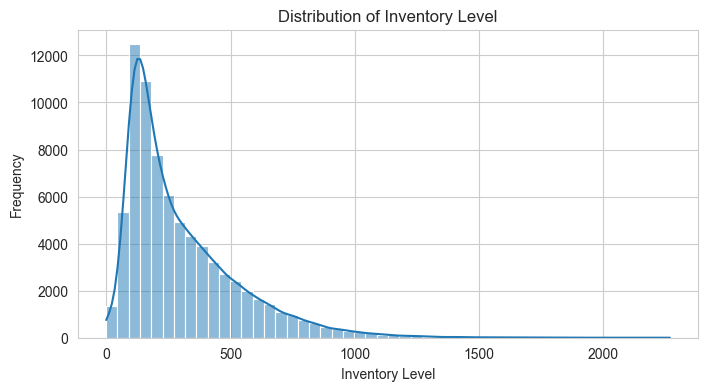

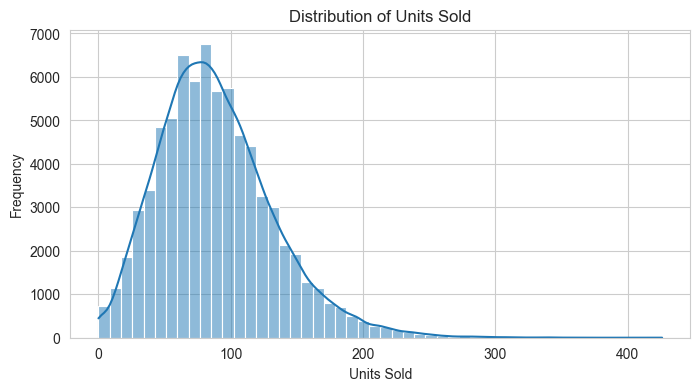

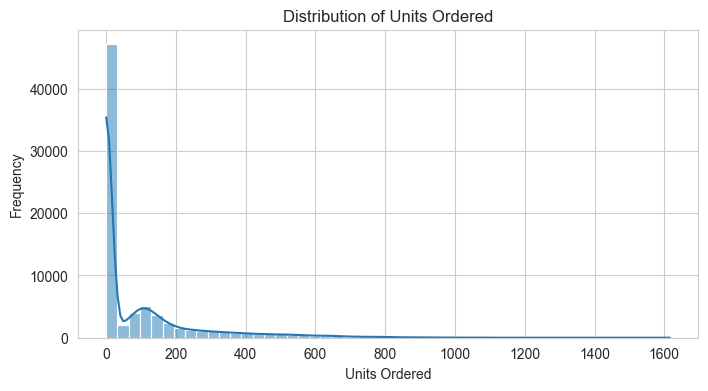

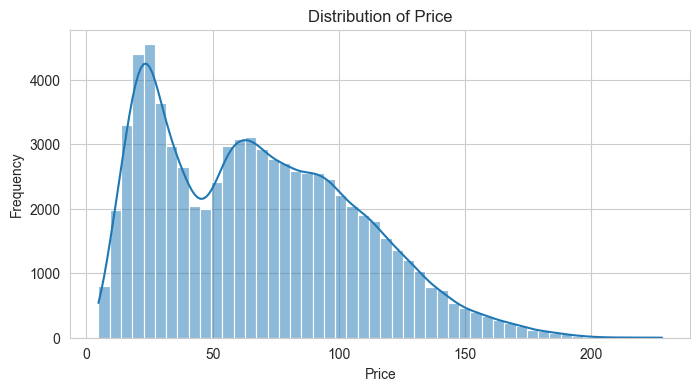

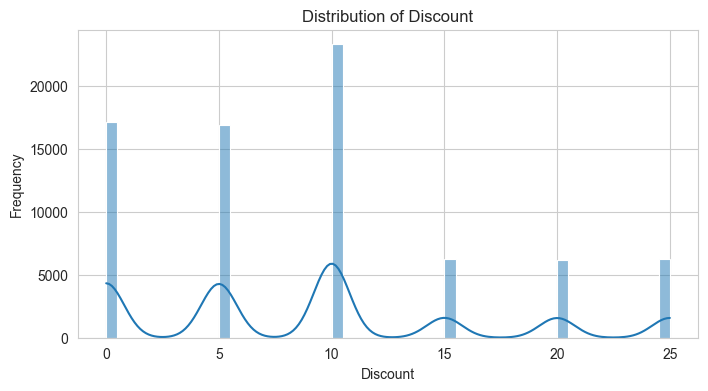

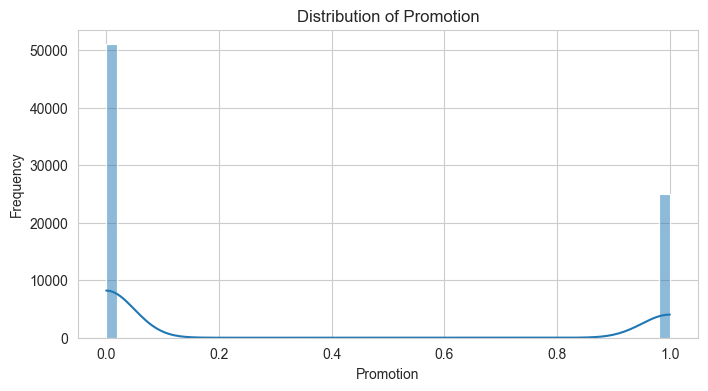

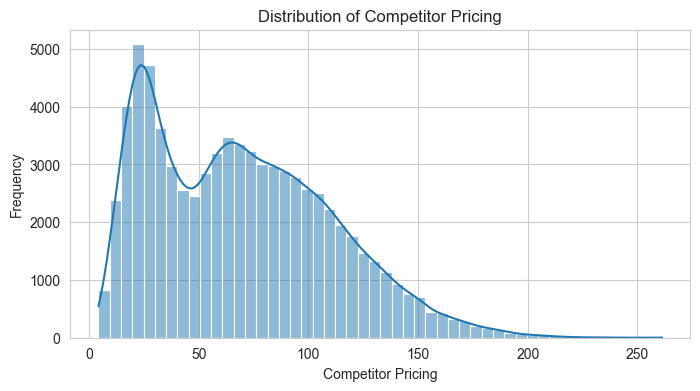

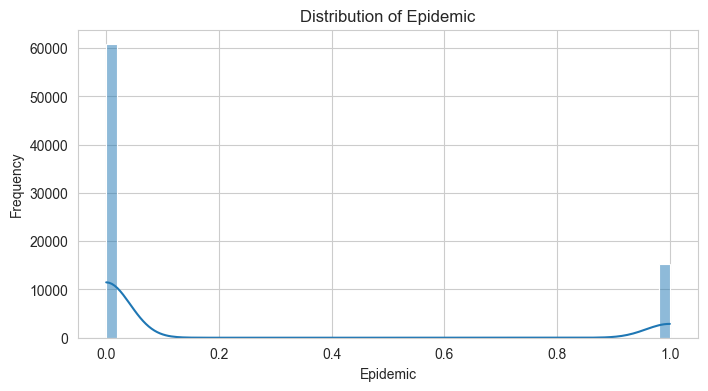

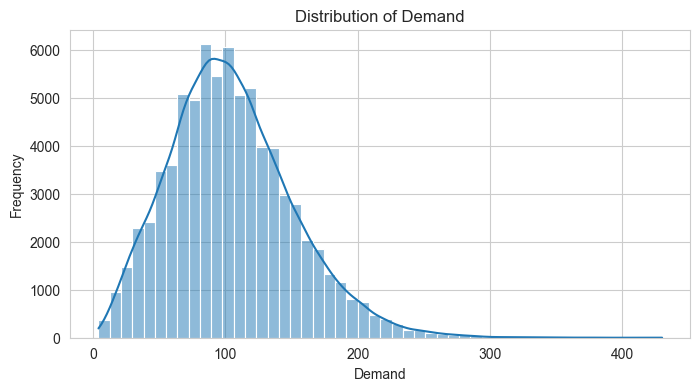

In [19]:
for col in num_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True, bins=50)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

## Categorical Columns Analysis

In [14]:
df.columns

Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Discount',
       'Weather Condition', 'Promotion', 'Competitor Pricing', 'Seasonality',
       'Epidemic', 'Demand'],
      dtype='str')

In [15]:
cat_cols = df.select_dtypes(include="str").columns
cat_cols

Index(['Store ID', 'Product ID', 'Category', 'Region', 'Weather Condition',
       'Seasonality'],
      dtype='str')

C:\Users\bharg\AppData\Local\Temp\ipykernel_11780\2263814399.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y="Demand", order=sorted_order, palette="seismic")


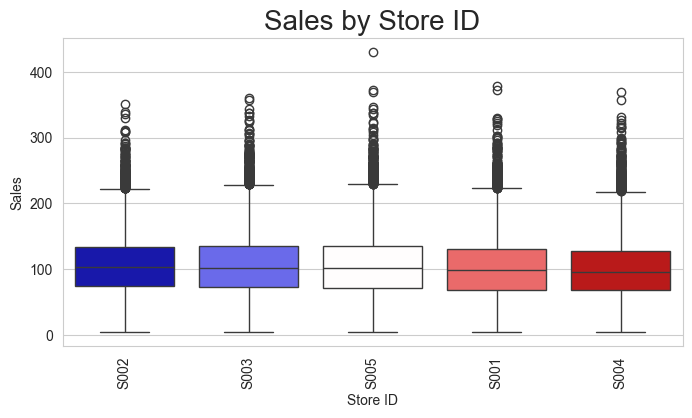

C:\Users\bharg\AppData\Local\Temp\ipykernel_11780\2263814399.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y="Demand", order=sorted_order, palette="seismic")


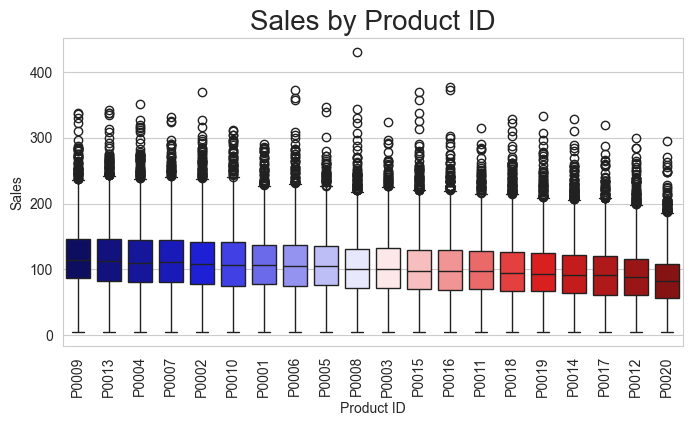

C:\Users\bharg\AppData\Local\Temp\ipykernel_11780\2263814399.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y="Demand", order=sorted_order, palette="seismic")


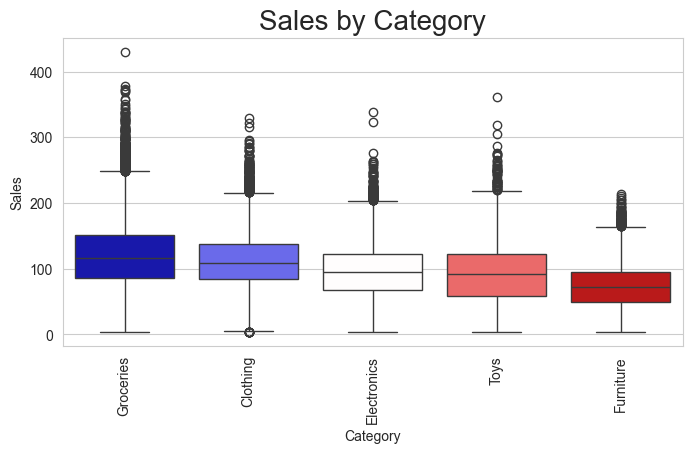

C:\Users\bharg\AppData\Local\Temp\ipykernel_11780\2263814399.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y="Demand", order=sorted_order, palette="seismic")


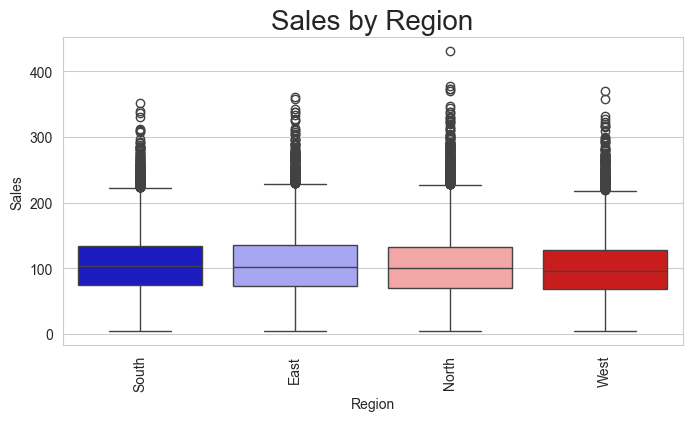

C:\Users\bharg\AppData\Local\Temp\ipykernel_11780\2263814399.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y="Demand", order=sorted_order, palette="seismic")


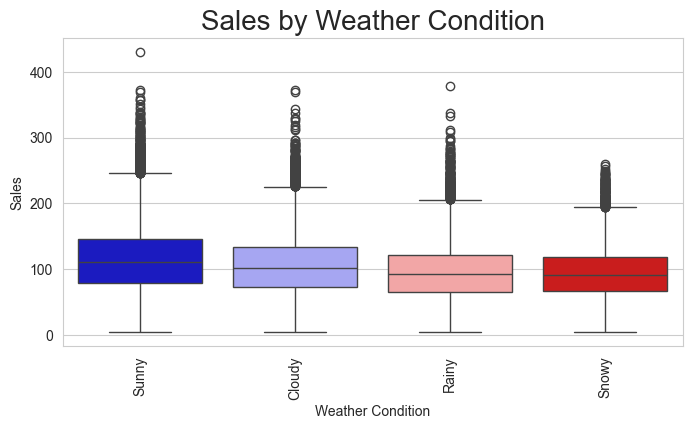

C:\Users\bharg\AppData\Local\Temp\ipykernel_11780\2263814399.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y="Demand", order=sorted_order, palette="seismic")


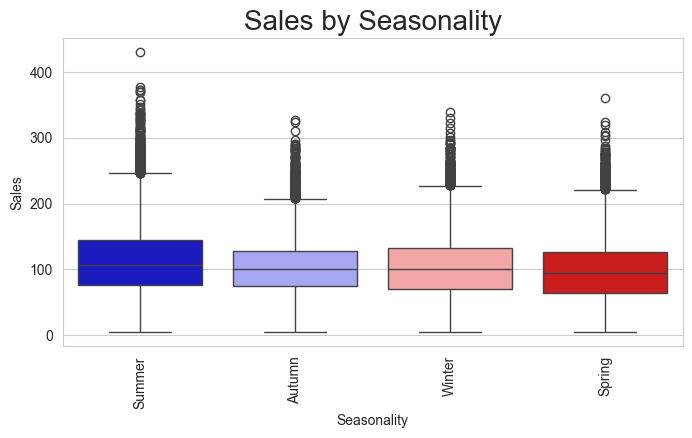

In [16]:
for col in cat_cols:
    sorted_order = df.groupby(col)["Demand"].mean().sort_values(ascending=False).index

    plt.figure(figsize=(8, 4))

    sns.boxplot(data=df, x=col, y="Demand", order=sorted_order, palette="seismic")

    plt.title(f"Sales by {col}", fontsize=20)
    plt.xlabel(col)
    plt.ylabel("Sales")
    plt.xticks(rotation=90)
    plt.show()

## Time-Series Analysis

In [17]:
df.columns

Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Discount',
       'Weather Condition', 'Promotion', 'Competitor Pricing', 'Seasonality',
       'Epidemic', 'Demand'],
      dtype='str')

In [18]:
df["Year"] = df["Date"].dt.year
df["Weekday"] = df["Date"].dt.day_name()
df["Day"] = df["Date"].dt.day
df["Month"] = df["Date"].dt.month
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand,Year,Weekday,Day,Month
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115,2022,Saturday,1,1
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229,2022,Saturday,1,1
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157,2022,Saturday,1,1
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52,2022,Saturday,1,1
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59,2022,Saturday,1,1


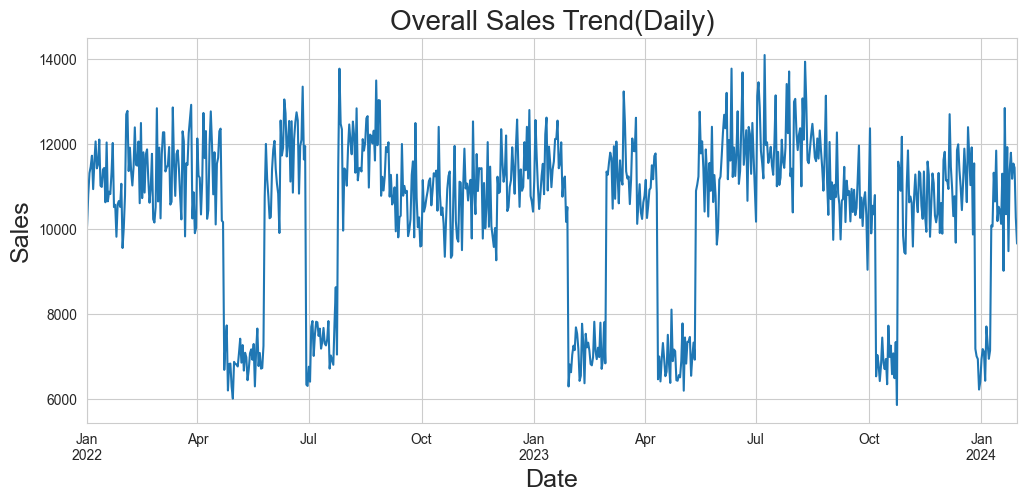

In [19]:
df.groupby("Date")["Demand"].sum().plot(kind="line", figsize=(12, 5))
plt.title("Overall Sales Trend(Daily)", fontsize=20)
plt.xlabel("Date", fontsize=18)
plt.ylabel("Sales", fontsize=18)
plt.show()

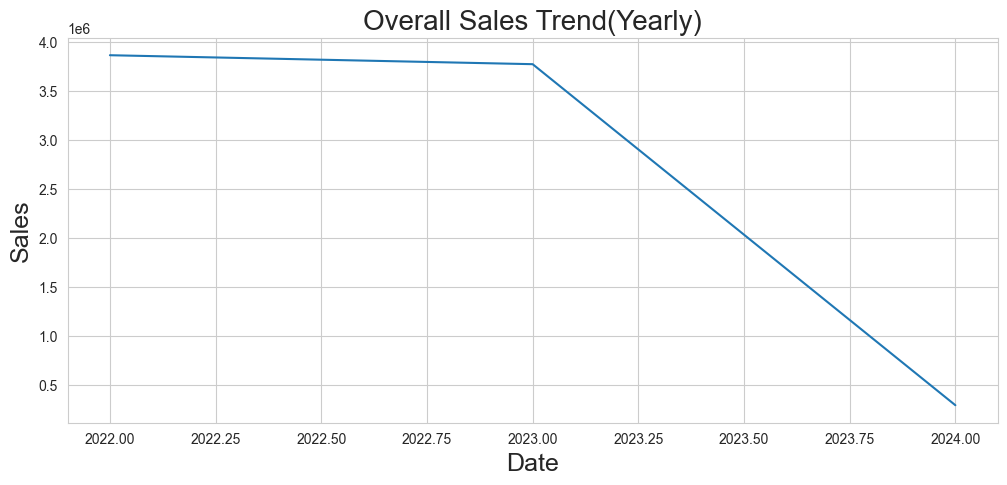

In [20]:
df.groupby("Year")["Demand"].sum().plot(kind="line", figsize=(12, 5))
plt.title("Overall Sales Trend(Yearly)", fontsize=20)
plt.xlabel("Date", fontsize=18)
plt.ylabel("Sales", fontsize=18)
plt.show()

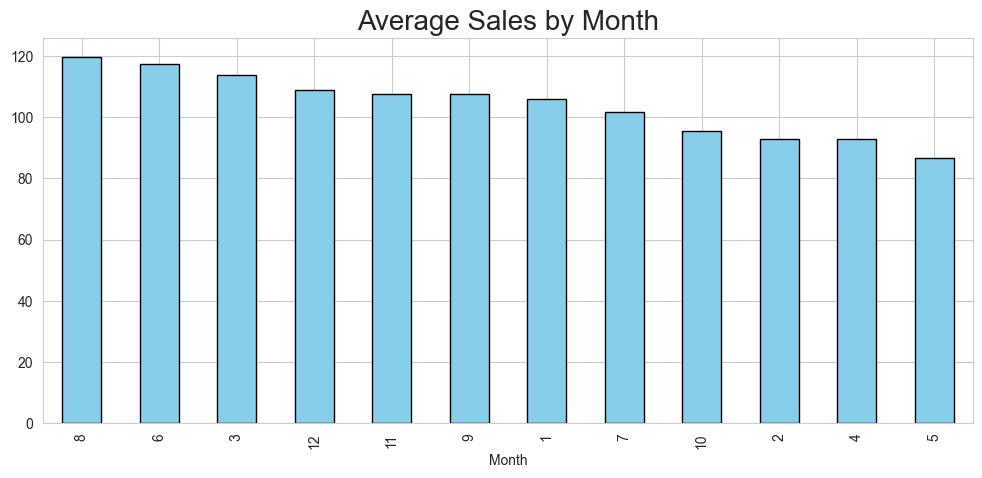

In [21]:
monthly_demand = df.groupby("Month")["Demand"].mean().sort_values(ascending=False)
monthly_demand.plot(kind="bar", figsize=(12, 5), edgecolor="black", color="skyblue")
plt.title("Average Sales by Month", fontsize=20)
plt.show()

## Create Features

In [22]:
df["DiscountedPrice"] = df["Price"] * (1 - df["Discount"] / 100)
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,...,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand,Year,Weekday,Day,Month,DiscountedPrice
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,...,0,85.73,Winter,0,115,2022,Saturday,1,1,69.084
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,...,1,92.02,Winter,0,229,2022,Saturday,1,1,68.136
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,...,1,60.08,Winter,0,157,2022,Saturday,1,1,56.646
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,...,0,85.19,Winter,0,52,2022,Saturday,1,1,78.867
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,...,0,51.63,Winter,0,59,2022,Saturday,1,1,54.410


In [23]:
df["SellThroughRate"] = df["Units Sold"] / df["Inventory Level"]
df["SellThroughRate"].describe()

count    75594.000000
mean         0.437580
std          0.298007
min          0.003150
25%          0.190807
50%          0.350475
75%          0.642276
max          1.000000
Name: SellThroughRate, dtype: float64

In [24]:
df = df.fillna(0)
df.isna().sum()

Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Price                 0
Discount              0
Weather Condition     0
Promotion             0
Competitor Pricing    0
Seasonality           0
Epidemic              0
Demand                0
Year                  0
Weekday               0
Day                   0
Month                 0
DiscountedPrice       0
SellThroughRate       0
dtype: int64

In [25]:
df.groupby("Category")["Demand"].agg(["mean", "sum", "std"]).sort_values(
    by="sum", ascending=False
).reset_index()

,Category,mean,sum,std
0,Groceries,120.976447,3677684,48.362730
1,Clothing,112.619737,1369456,41.022968
2,Furniture,73.581140,1006590,32.336141
3,Toys,92.606955,985338,46.170390
4,Electronics,97.482018,889036,40.557859


In [26]:
df.groupby(["Region", "Seasonality"])["Demand"].mean()

Region  Seasonality
East    Autumn         106.353297
        Spring         100.168478
        Summer         115.388315
        Winter         104.273571
North   Autumn         103.065797
        Spring          97.399457
        Summer         112.843750
        Winter         102.017738
South   Autumn         104.464560
        Spring         100.328804
        Summer         115.089946
        Winter         107.733095
West    Autumn         100.165385
        Spring          93.219293
        Summer         108.111141
        Winter         100.988810
Name: Demand, dtype: float64

In [27]:
df.groupby("Promotion")["Demand"].mean()

Promotion
0     95.026843
1    123.269400
Name: Demand, dtype: float64

In [28]:
pd.pivot_table(df, values="Demand", index="Month", columns="Category", aggfunc="mean")

Category,Clothing,Electronics,Furniture,Groceries,Toys
Month,,,,,
1,126.997962,99.519022,75.690821,117.399457,94.242236
2,128.966518,84.184524,61.625992,103.522768,68.885204
3,105.835685,108.120968,84.015233,126.561694,128.273041
4,106.972917,85.916667,63.005556,105.111250,85.753571
5,108.650202,79.577957,56.036738,98.637903,71.756912
6,105.670833,106.922222,79.908333,147.772500,100.825000
7,107.838710,87.418011,66.156810,128.744355,74.366359
8,107.871976,109.733871,83.524194,149.875403,102.794931
9,105.118750,105.015278,81.854630,122.239167,102.722619


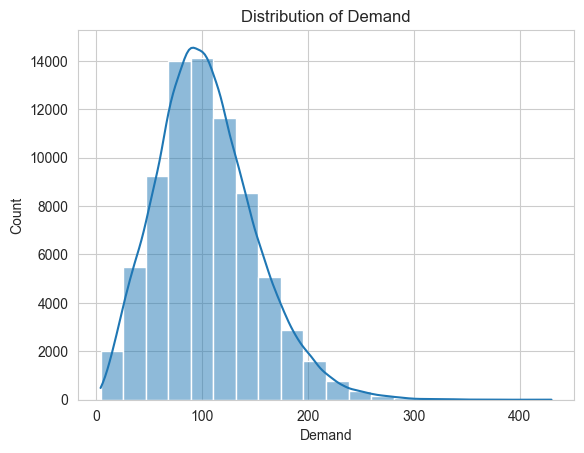

In [29]:
sns.histplot(df["Demand"], bins=20, kde=True)
plt.title("Distribution of Demand")
plt.show()

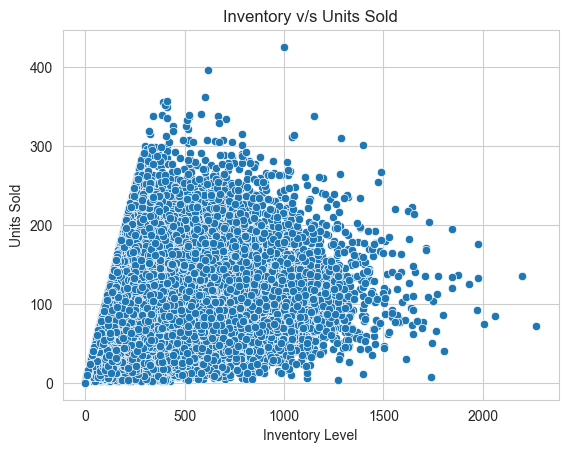

In [30]:
sns.scatterplot(data=df, x="Inventory Level", y="Units Sold")
plt.title("Inventory v/s Units Sold")
plt.show()

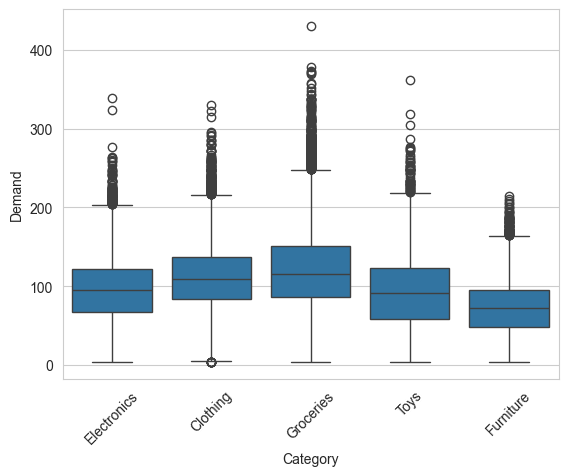

In [31]:
sns.boxplot(data=df, x="Category", y="Demand")
plt.xticks(rotation=45)
plt.show()

C:\Users\bharg\AppData\Local\Temp\ipykernel_11780\1726331765.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="Promotion", y="Demand", palette="viridis")


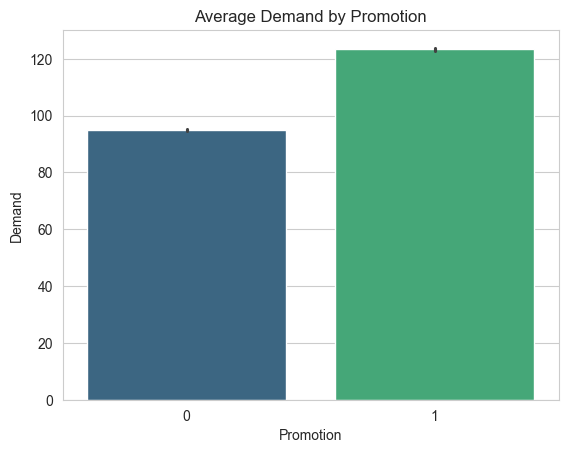

In [32]:
sns.barplot(data=df, x="Promotion", y="Demand", palette="viridis")
plt.title("Average Demand by Promotion")
plt.show()

In [33]:
df.columns

Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Discount',
       'Weather Condition', 'Promotion', 'Competitor Pricing', 'Seasonality',
       'Epidemic', 'Demand', 'Year', 'Weekday', 'Day', 'Month',
       'DiscountedPrice', 'SellThroughRate'],
      dtype='str')

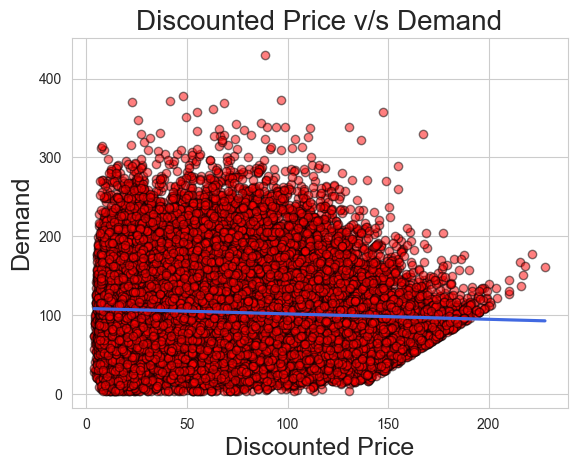

In [34]:
sns.regplot(
    data=df,
    x="DiscountedPrice",
    y="Demand",
    color="RoyalBlue",
    scatter_kws={"alpha": 0.5, "color": "red", "edgecolor": "black"},
)
plt.title("Discounted Price v/s Demand", fontsize=20)
plt.xlabel("Discounted Price", fontsize=18)
plt.ylabel("Demand", fontsize=18)
plt.show()

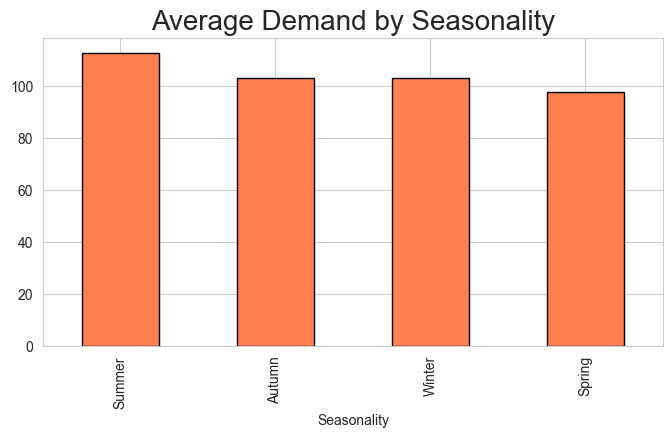

In [35]:
df.groupby("Seasonality")["Demand"].mean().sort_values(ascending=False).plot(
    kind="bar", figsize=(8, 4), color="coral", edgecolor="black"
)
plt.title("Average Demand by Seasonality", fontsize=20)
plt.show()

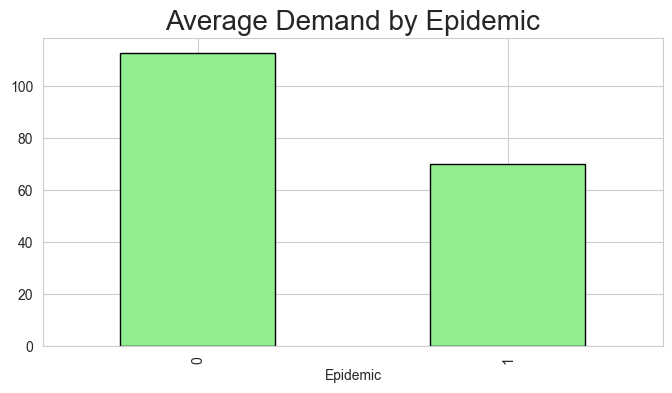

In [36]:
df.groupby("Epidemic")["Demand"].mean().sort_values(ascending=False).plot(
    kind="bar", figsize=(8, 4), color="lightgreen", edgecolor="black"
)
plt.title("Average Demand by Epidemic", fontsize=20)
plt.show()

## Corelation Analysis

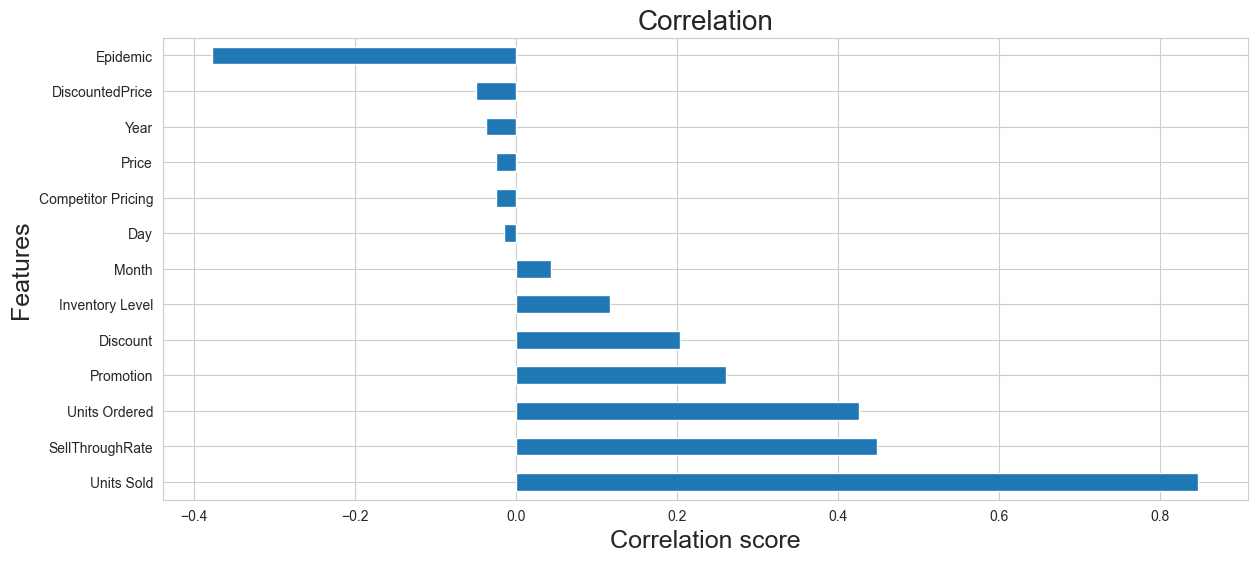

In [45]:
plt.figure(figsize=(14, 6))
df.corr(numeric_only=True, method="spearman")["Demand"].drop(["Demand"]).sort_values(
    ascending=False
).plot(kind="barh")
plt.title("Correlation", fontsize=20)
plt.xlabel("Correlation score", fontsize=18)
plt.ylabel("Features", fontsize=18)
plt.show()

# **Save the Features**

In [ ]:
file_path = Path.cwd().resolve().parent / "data/cleaned_demand_forecasting.parquet"
file_path.parent.mkdir(parents=True, exist_ok=True)
df.to_parquet(file_path, index=False)